In [1]:
"""
Let's try something interesting tonight
"""

"\nLet's try something interesting tonight\n"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("data/housing.csv")

In [4]:
data.dropna(inplace=True)
data.info()
#data['ocean_proximity'].value_counts()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [5]:
from sklearn.model_selection import train_test_split

X = data.drop(['median_house_value'], axis=1)
y = data ['median_house_value']

In [6]:
#Le test_size c'est pour dire que 20% des données seront utilisées pour le test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

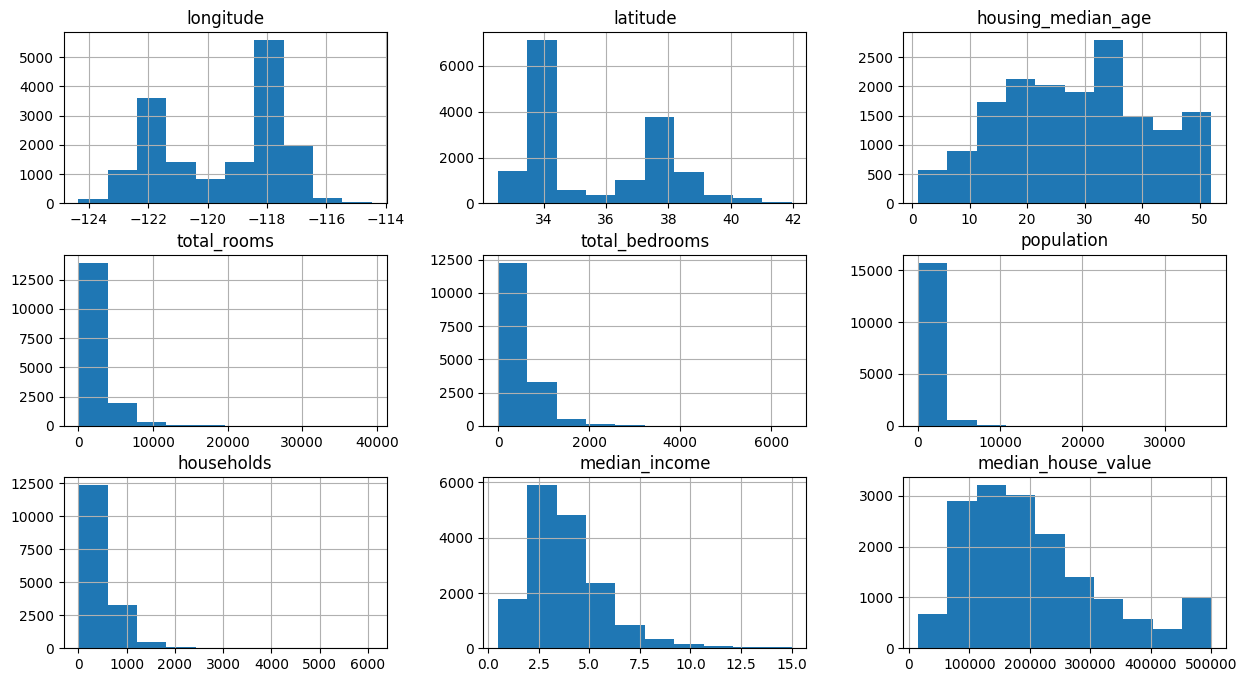

In [7]:
train_data = X_train.join(y_train)

train_data.hist(figsize=(15, 8))

<Axes: >

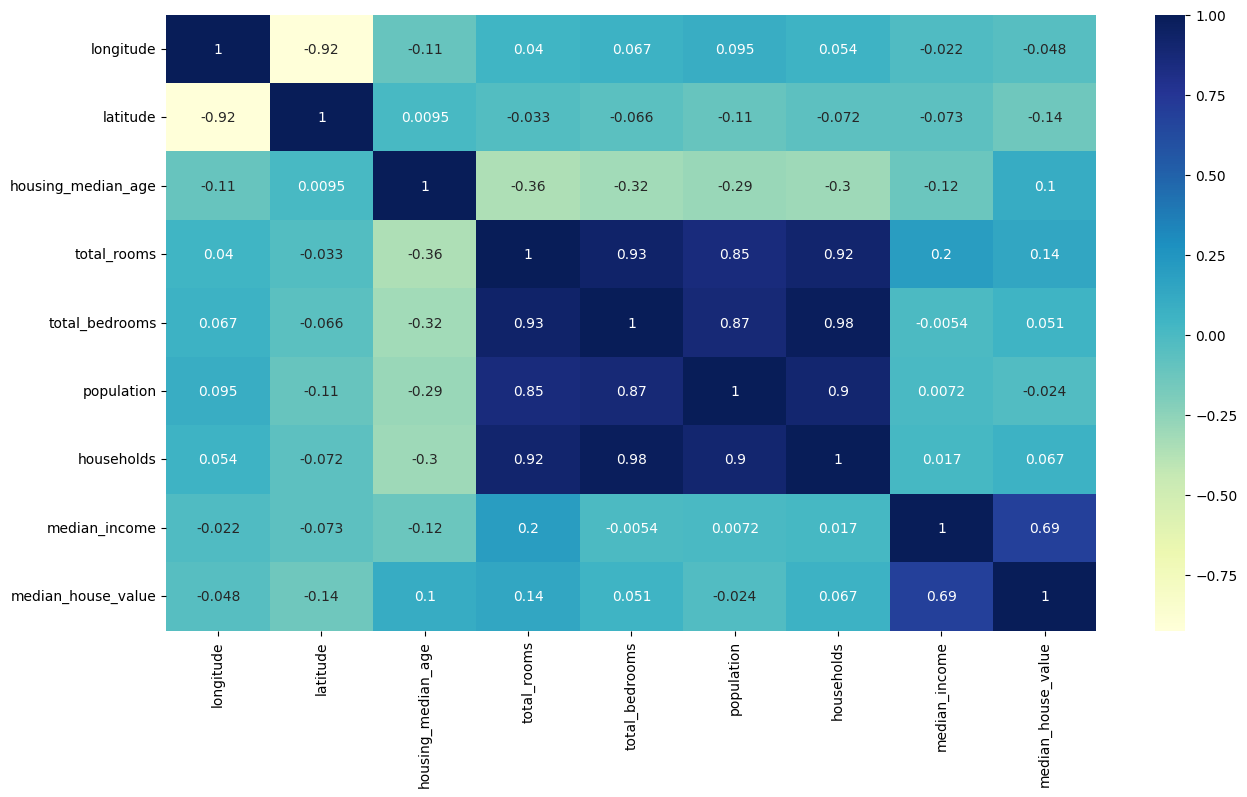

In [8]:
train_data.corr(numeric_only=True)
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

In [9]:
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

In [10]:
"""get_dummies permet de transformer les variables texte en variables numériques
Si mon dataset était comme ceci: 
| id | color |
| -- | ----- |
| 1  | red   |
| 2  | blue  |
| 3  | green |

 data = pd.get_dummies(data, columns=['color']) ceci le transforme en ça
| id | color_blue | color_green | color_red |
| -- | ---------- | ----------- | --------- |
| 1  | 0          | 0           | 1         |
| 2  | 1          | 0           | 0         |
| 3  | 0          | 1           | 0         |

Ceci pd.get_dummies(train_data.ocean_proximity) crée un nouveau dataframe avec seulement les colonnes encodées 
 j'ajoute dtype=int pour préciser que je veux 0/1 au lieu de false/true
"""
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity, dtype=int)).drop(['ocean_proximity'], axis=1)


<Axes: >

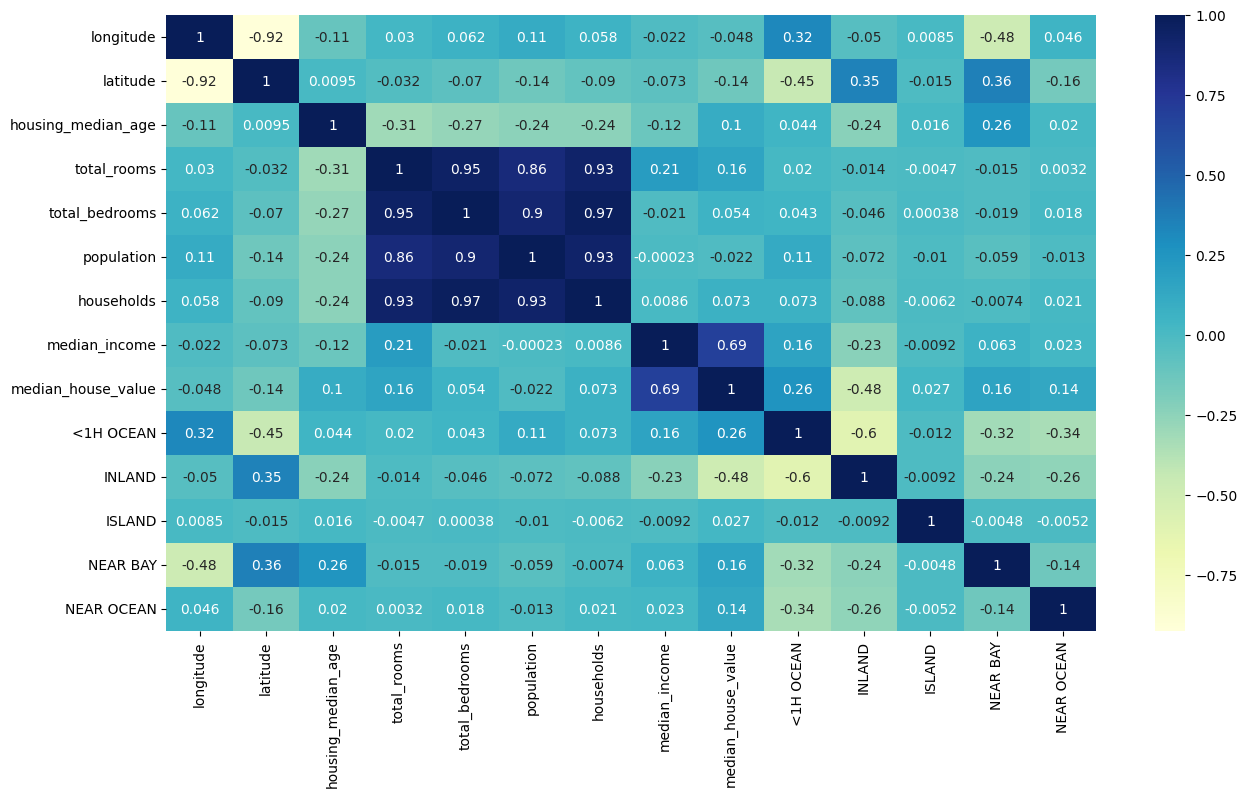

In [11]:
train_data.corr(numeric_only=True)
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

<Axes: xlabel='latitude', ylabel='longitude'>

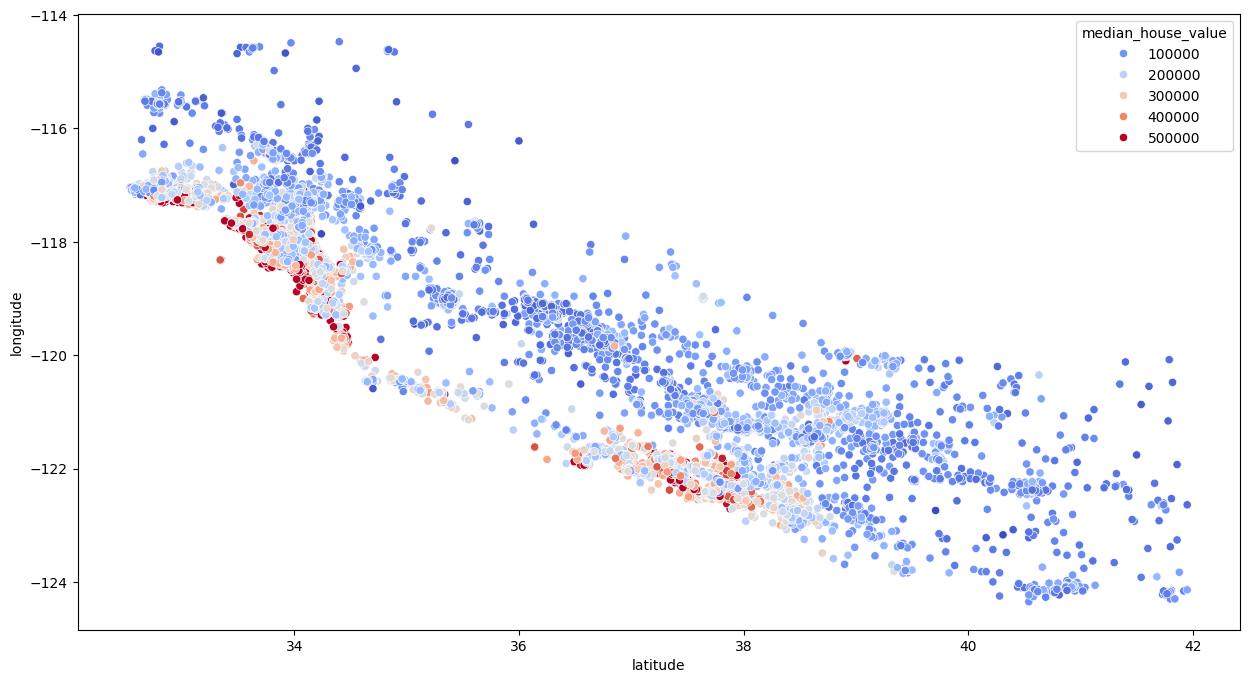

In [12]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x="latitude", y="longitude", data=train_data, hue="median_house_value", palette="coolwarm")

In [13]:
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_ratio'] = train_data['total_rooms'] / train_data['households']

<Axes: >

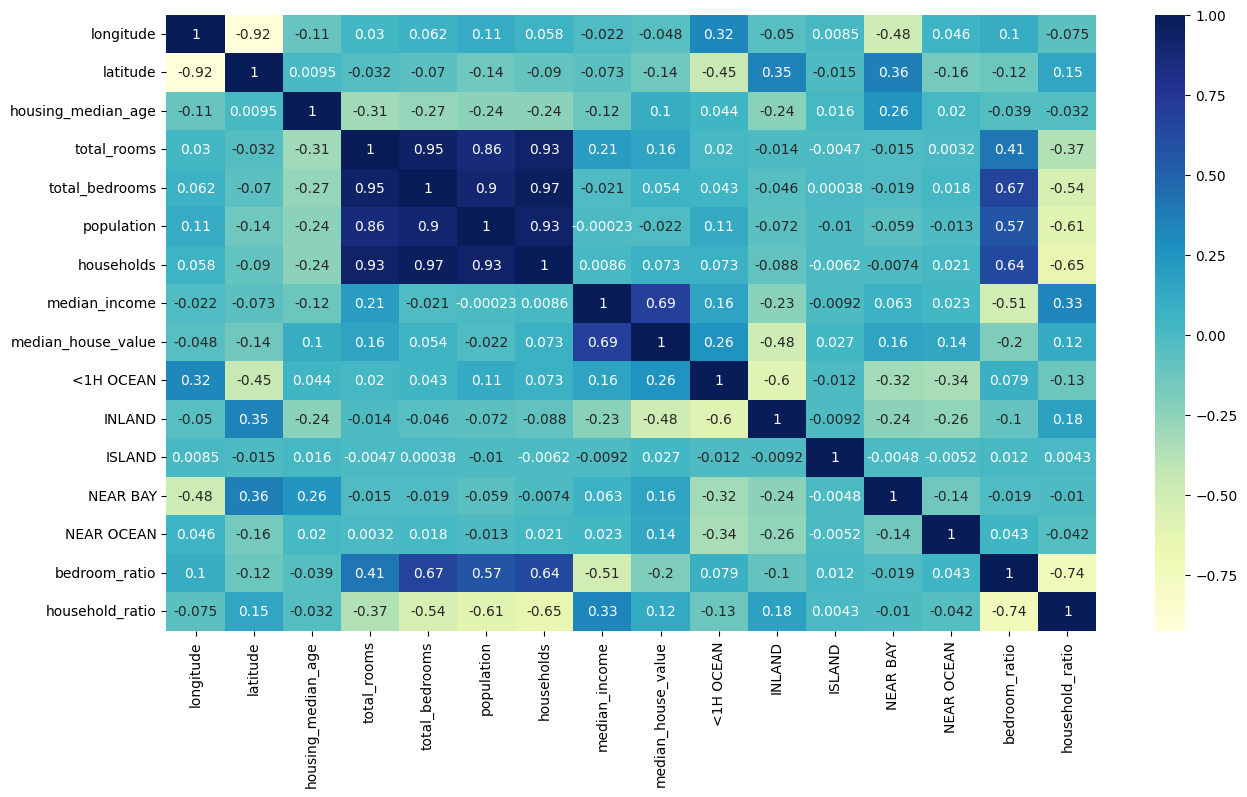

In [14]:
train_data.corr(numeric_only=True)
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

In [15]:
"""
StandardScaler change l’échelle des nombres pour que toutes les colonnes
soient comparables. (par exemple s'il y a âge et salaire, salire est généralement très grand)
La moyenne est simplement la valeur du milieu, donc après transformation, la moyenne devient alors 0 après StandardScaler.
L'écart-type mesure à quel point les données sont dispersées. Donc après StandardScaler, l'écart-type devient 1.
"""

"\nStandardScaler change l’échelle des nombres pour que toutes les colonnes\nsoient comparables. (par exemple s'il y a âge et salaire, salire est généralement très grand)\nLa moyenne est simplement la valeur du milieu, donc après transformation, la moyenne devient alors 0 après StandardScaler.\nL'écart-type mesure à quel point les données sont dispersées. Donc après StandardScaler, l'écart-type devient 1.\n"

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train, y_train = train_data.drop(['median_house_value'], axis=1), train_data['median_house_value']
X_train_s = scaler.fit_transform(X_train)

reg = LinearRegression()
reg.fit(X_train_s, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
test_data = X_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)

test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity, dtype=int)).drop(['ocean_proximity'], axis=1)

test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['household_ratio'] = test_data['total_rooms'] / test_data['households']

# X_test, y_test = test_data.drop(['median_house_value'], axis=1), test_data['median_house_value']


In [18]:
X_test, y_test = test_data.drop(['median_house_value'], axis=1), test_data['median_house_value']


In [19]:
#J'ai ajouté ceci pour corriger l'erreur
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_test_s = scaler.transform(X_test)

In [20]:
"""
Le score renvoie le coefficient de détermination 
| R²  | Interprétation                             |
| --- | ------------------------------------------ |
| 1   | Parfait : toutes les prédictions exactes   |
| 0   | Le modèle prédit aussi bien que la moyenne |
| < 0 | Le modèle est pire qu’une simple moyenne   |


0.85 → ton modèle explique 85% de la variance → très bon

0.5 → explique 50% → moyen

-0.1 → prédit moins bien que la moyenne → problème

"""

reg.score(X_test_s, y_test)

0.6687407117584969

In [21]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()

forest.fit(X_train_s, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
#ça retourne le R au carré
forest.score(X_test_s, y_test)

0.8205504789823279

In [23]:
#ça retourne le R au carré
forest.score(X_train_s, y_train)

0.9740513730139133

In [24]:
"""
On crée le param_grid pour tester plusieurs combinaisons de paramètres


Le cv signifie Cross Validation, cv=5 signifie que les données d'entraînement sont divisées en 5 parties : 4 parties pour l'entraînement et une partie pour le test


scoring="neg_mean_squared_error" est une métrique qui mesure la différence entre la vraie valeur et la prédiction, dans notre cas ici elle est négative
"""

'\nOn crée le param_grid pour tester plusieurs combinaisons de paramètres\n\n\nLe cv signifie Cross Validation, cv=5 signifie que les données d\'entraînement sont divisées en 5 parties : 4 parties pour l\'entraînement et une partie pour le test\n\n\nscoring="neg_mean_squared_error" est une métrique qui mesure la différence entre la vraie valeur et la prédiction, dans notre cas ici elle est négative\n'

In [25]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators" : [100, 200, 300],
    "min_samples_split" : [2, 4],
    "max_depth" : [None, 4, 8],
}

grid_search = GridSearchCV(forest, param_grid, cv=5, 
                           scoring="neg_mean_squared_error",
                           return_train_score=True, n_jobs=-1,
    verbose=2)

grid_search.fit(X_train_s, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [None, 4, ...], 'min_samples_split': [2, 4], 'n_estimators': [100, 200, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,300


In [37]:
best_forest = grid_search.best_estimator_
best_forest

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
"""
Le score nous permet de déterminer les performances de notre modèle

| Score | Signification  |
| ----- | -------------- |
| 1     | parfait        |
| 0.8   | très bon       |
| 0.5   | moyen          |
| 0     | modèle inutile |
| < 0   | très mauvais   |

"""

'\nLe score nous permet de déterminer les performances de notre modèle\n\n| Score | Signification  |\n| ----- | -------------- |\n| 1     | parfait        |\n| 0.8   | très bon       |\n| 0.5   | moyen          |\n| 0     | modèle inutile |\n| < 0   | très mauvais   |\n\n'

In [28]:
best_forest.score(X_test_s, y_test)

0.8210069288277376

In [29]:
grid_search.best_estimator_.score(X_test_s, y_test)

0.8210069288277376

In [30]:
"""
joblib est une version plus rapide et donc améliorée de pickle, elle permet d'enregistrer des objets ou des structures
de données Python par exemple notre modèle entraîné, pour ne plus avoir à l'entraîner à nouveau.
"""

"\njoblib est une version plus rapide et donc améliorée de pickle, elle permet d'enregistrer des objets ou des structures\nde données Python par exemple notre modèle entraîné, pour ne plus avoir à l'entraîner à nouveau.\n"

In [31]:
import joblib as jb
jb.dump(best_forest, "model/best_forest_model.pkl")
jb.dump(scaler, "model/scaler.pkl")

['model/scaler.pkl']